# 3회차 실습: 행렬을 **눈으로** 이해하기

이번 노트북의 목표는 계산 확인이 아니라, 이번 회차의 두 그림을 **그림으로 체득**하는 것이다.

1. **Column picture** — $A\mathbf{x}$ = 열들을 $\mathbf{x}$배로 섞은 벡터 합
2. **Column space** — $\mathbf{x}$를 전부 바꾸면 $A\mathbf{x}$는 어디까지 도달하는가


In [1]:
!pip install -q koreanize-matplotlib
import numpy as np, matplotlib.pyplot as plt, koreanize_matplotlib  # noqa
CR, NV, GD = '#862633', '#22386B', '#9A6B00'
A = np.array([[2., 1.], [1., 3.]])       # 이 노트북에서 계속 쓸 행렬
print('A =\n', A)


A =
 [[2. 1.]
 [1. 3.]]


## ① Column picture: $A\mathbf{x}$ = 열들을 $\mathbf{x}$배로 섞은 합

$A\mathbf{x} = x_1\mathbf{a}_1 + x_2\mathbf{a}_2$. 즉 1열을 $x_1$배, 2열을 $x_2$배 해서 **이어 붙인**(tip-to-tail) 벡터 합이 결과다.


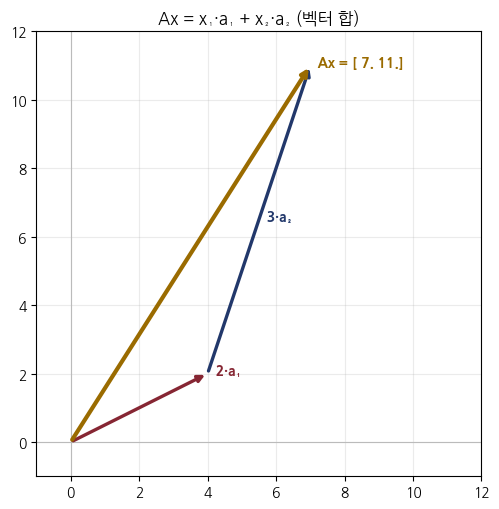

In [7]:
x = np.array([2., 3.])                # 이 x로 열을 섞는다 (원하는 값으로 바꿔 실험)
a1, a2 = A[:, 0], A[:, 1]
Ax = A @ x                            # = x[0]*a1 + x[1]*a2

plt.figure(figsize=(5.2, 5.2))
plt.annotate('', x[0]*a1, (0, 0),      arrowprops=dict(arrowstyle='-|>', color=CR, lw=2.4))
plt.annotate('', Ax,      x[0]*a1,     arrowprops=dict(arrowstyle='-|>', color=NV, lw=2.4))
plt.annotate('', Ax,      (0, 0),      arrowprops=dict(arrowstyle='-|>', color=GD, lw=3))
plt.text(*(x[0]*a1), f'  {x[0]:.0f}·a₁', color=CR, fontweight='bold')
plt.text(*((Ax + x[0]*a1) / 2), f'  {x[1]:.0f}·a₂', color=NV, fontweight='bold')
plt.text(*Ax, f'  Ax = {Ax}', color=GD, fontweight='bold')

# 화살표(annotate)는 축 범위를 자동 조정하지 않는다 → 모든 점이 보이도록 범위를 직접 지정
lim = np.abs(np.stack([x[0]*a1, x[1]*a2, Ax])).max() + 1
plt.xlim(-1, lim); plt.ylim(-1, lim)
plt.axhline(0, color='#bbb', lw=.8); plt.axvline(0, color='#bbb', lw=.8)
plt.gca().set_aspect('equal'); plt.grid(alpha=.25); plt.title('Ax = x₁·a₁ + x₂·a₂ (벡터 합)')
plt.tight_layout(); plt.show()


## ② Column space: $\mathbf{x}$를 전부 바꾸면 어디까지 도달하나

$\mathbf{x}$를 온갖 값으로 바꾸며 $A\mathbf{x}$를 모두 찍으면, 그 **도달 가능 영역**이 곧 $\mathrm{col}(A)$다. 열이 **독립**이면 평면 전체를 채우고, 열이 **종속**(한 열이 다른 열의 배수)이면 **직선**으로 무너진다.


In [ ]:
xs = np.random.default_rng(0).uniform(-3, 3, (2, 1200))
Aind = A                              # 독립 열
Adep = np.array([[1., 2.], [2., 4.]]) # 종속 열 (a₂ = 2a₁)

fig, ax = plt.subplots(1, 2, figsize=(9, 4.5))
for a, M, ttl in [(ax[0], Aind, 'col(A) = 평면 (열 독립)'), (ax[1], Adep, 'col(A) = 직선 (열 종속)')]:
    P = M @ xs
    a.scatter(P[0], P[1], s=5, color=CR, alpha=.25)
    for c, col in zip(M.T, [CR, NV]):
        a.annotate('', c, (0,0), arrowprops=dict(arrowstyle='-|>', color=col, lw=2.5))
    a.set_title(ttl); a.set_aspect('equal'); a.grid(alpha=.2)
plt.suptitle('모든 x에 대한 Ax의 집합 = col(A)   ·   Ax=b는 b가 이 영역 안일 때만 풀린다', fontsize=11)
plt.tight_layout(); plt.show()


## 정리 — 같은 $A\mathbf{x}$, 두 가지 눈

- **Column picture**: $A\mathbf{x}$ = 열들을 $\mathbf{x}$배로 섞은 벡터 합.
- **Column space**: 모든 $A\mathbf{x}$의 집합 = $\mathrm{col}(A)$. 열의 독립성이 그 차원(평면/직선)을 정하고, $A\mathbf{x}=\mathbf{b}$는 $\mathbf{b}$가 이 영역 안에 있을 때만 풀린다. → 6·7회차(부분공간·rank)의 뿌리.
- (평면 전체가 변형되는 **선형변환** 관점은 기저·차원을 배운 뒤 Part 2에서 정식으로 다룬다.)
